In [1]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
import costfun.costfun as cost
import utils.figures as fig_help
import utils.tools as tools
from RandomMatrixTheory import goe
from Quad_tools import *

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as gamma_fun
from scipy.special import lambertw
from scipy.special import voigt_profile
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import splrep, splev
 
# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

DIM = 1
modello = 'RP'


def base_dir(model, d, BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/{model}/" + (f"" if model == 'PLRB' or model == 'RP' else  f"dim={d}/") + ( '' if model == 'RP' else (f"PBC/" if BC else f"OBC/") )
    return dirx

print(base_dir(modello, DIM))
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/QHamSolver/Quadratic/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
../results/RP/


## TESTS

[0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2. ]


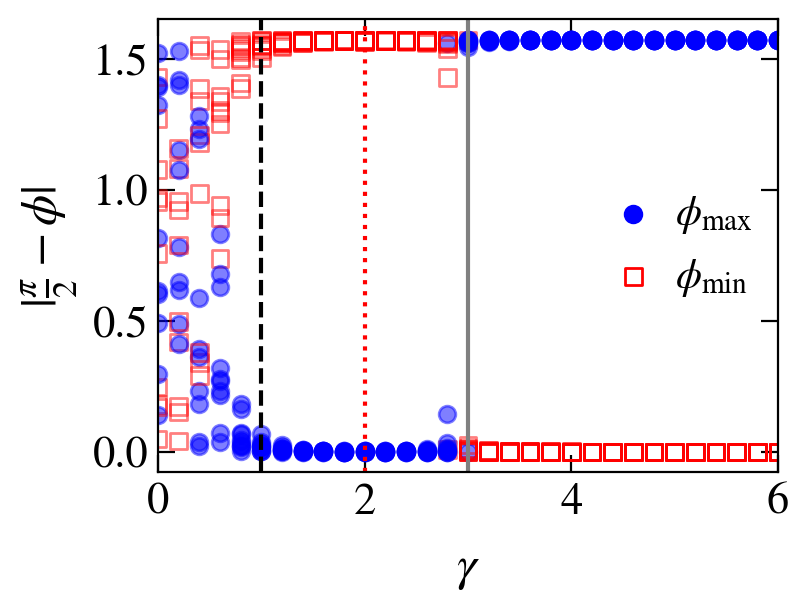

In [16]:
L = 10
w = 2
J = 1
g = 1.5
op=0
modello = 'RP'
# prefix = base_dir(model=modello, d=DIM) + 'GOE/GeometricTensor/realisation=0/'

sizes = np.arange(8, 16, 1)

DIM = 1
g_crit = 2

window = 3

gamma_vals = np.arange(0.0, 6.01, 0.2)
gamma_plot = np.round(np.arange(0.9, 2.01, 0.1), 2)
print(gamma_plot)


dim = 2**L
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200)

depsilon = 0.05
_eps_ = np.arange(depsilon, 1.0-depsilon, 0.02)
_eps_ = _eps_[_eps_ <= 0.91]
_eps_ = _eps_[_eps_ >= 0.1]


for r in range(10):
    for ii, gx in enumerate(gamma_vals):
        alfa = np.round(gx, 2)
        eta = 2 / (2 - gx)
        prefix = base_dir(model=modello, d=DIM) + 'GOE/GeometricTensor/realisation=%d/'%r
        name = prefix +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name):
            with h5py.File(name, "r") as file:
                phi_max = np.abs(np.pi/2 - np.array(file.get('phi_max'))[0])
                phi_min = np.abs(np.pi/2 - np.array(file.get('phi_min'))[0])
                axis.scatter(gx, phi_max, color = 'blue', marker = 'o', alpha=0.5)
                axis.scatter(gx, phi_min, color = 'red', facecolor='None', marker = 's', alpha=0.5)
        else:
            print(name)

axis.scatter(np.nan, np.nan, color = 'blue', marker = 'o', label=r"$\phi_{\rm max}$")
axis.scatter(np.nan, np.nan, color = 'red', facecolor='None',marker = 's', label=r"$\phi_{\rm min}$")
    
axis.axvline(x=1,    ls='--', c='k')
axis.axvline(x=2,    ls=':', c='red')
axis.axvline(x=3,    ls='-', c='gray')
axis.set_xlim(0, 6)

ylab = r"$\left|\frac{\pi}{2}-\phi\right|$"# if projected else r"$||\mathcal{A}_\lambda(\epsilon)||^2$"
fig_help.set_plot_elements(axis, ylabel=ylab, xlabel=r"$\gamma$", font_size=16, set_legend=True, xscale='linear', yscale='linear')
fig_help.set_legend(axis, fontsize=15, loc='center right', ncol = 1, columnspacing=0.6)

[0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2. ]
../results/RP/GOE/GeometricTensor2/realisation=10/_L=10,J=1,g=4.2.hdf5
../results/RP/GOE/GeometricTensor2/realisation=10/_L=10,J=1,g=4.4.hdf5
../results/RP/GOE/GeometricTensor2/realisation=10/_L=10,J=1,g=4.6.hdf5
../results/RP/GOE/GeometricTensor2/realisation=10/_L=10,J=1,g=4.8.hdf5
../results/RP/GOE/GeometricTensor2/realisation=10/_L=10,J=1,g=5.hdf5
../results/RP/GOE/GeometricTensor2/realisation=11/_L=10,J=1,g=4.2.hdf5
../results/RP/GOE/GeometricTensor2/realisation=11/_L=10,J=1,g=4.4.hdf5
../results/RP/GOE/GeometricTensor2/realisation=11/_L=10,J=1,g=4.6.hdf5
../results/RP/GOE/GeometricTensor2/realisation=11/_L=10,J=1,g=4.8.hdf5
../results/RP/GOE/GeometricTensor2/realisation=11/_L=10,J=1,g=5.hdf5
../results/RP/GOE/GeometricTensor2/realisation=12/_L=10,J=1,g=4.2.hdf5
../results/RP/GOE/GeometricTensor2/realisation=12/_L=10,J=1,g=4.4.hdf5
../results/RP/GOE/GeometricTensor2/realisation=12/_L=10,J=1,g=4.6.hdf5
../results/RP/GOE/GeometricTens

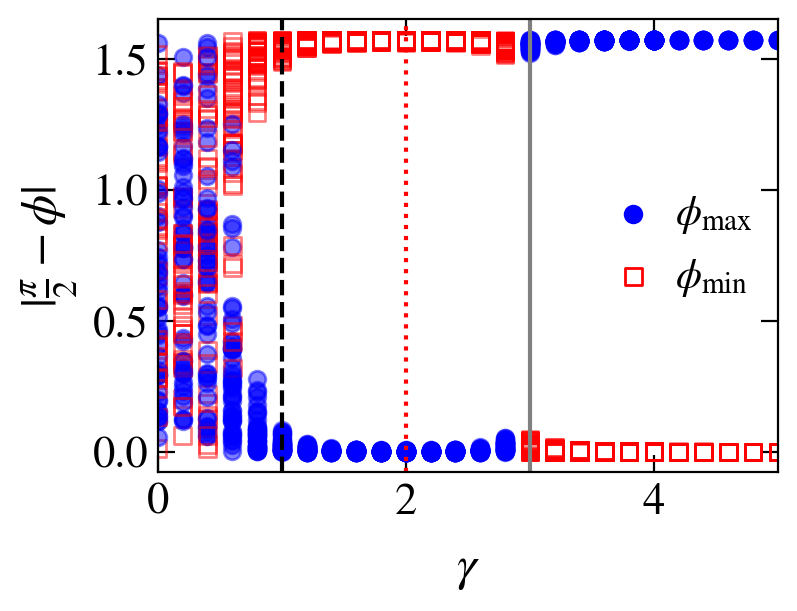

In [21]:
L = 10
w = 2
J = 1
g = 1.5
op=0
modello = 'RP'
# prefix = base_dir(model=modello, d=DIM) + 'GOE/GeometricTensor/realisation=0/'

sizes = np.arange(8, 16, 1)

DIM = 1
g_crit = 2

window = 3

gamma_vals = np.arange(0.0, 5.01, 0.2)
gamma_plot = np.round(np.arange(0.9, 2.01, 0.1), 2)
print(gamma_plot)


dim = 2**L
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200)

depsilon = 0.05
_eps_ = np.arange(depsilon, 1.0-depsilon, 0.02)
_eps_ = _eps_[_eps_ <= 0.91]
_eps_ = _eps_[_eps_ >= 0.1]


for r in range(50):
    for ii, gx in enumerate(gamma_vals):
        alfa = np.round(gx, 2)
        eta = 2 / (2 - gx)
        prefix = base_dir(model=modello, d=DIM) + 'GOE/GeometricTensor2/realisation=%d/'%r
        name = prefix +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name):
            with h5py.File(name, "r") as file:
                phi_max = np.abs(np.pi/2 - np.array(file.get('phi_max'))[0])
                phi_min = np.abs(np.pi/2 - np.array(file.get('phi_min'))[0])
                axis.scatter(gx, phi_max, color = 'blue', marker = 'o', alpha=0.5)
                axis.scatter(gx, phi_min, color = 'red', facecolor='None', marker = 's', alpha=0.5)
        else:
            print(name)

axis.scatter(np.nan, np.nan, color = 'blue', marker = 'o', label=r"$\phi_{\rm max}$")
axis.scatter(np.nan, np.nan, color = 'red', facecolor='None',marker = 's', label=r"$\phi_{\rm min}$")
    
axis.axvline(x=1,    ls='--', c='k')
axis.axvline(x=2,    ls=':', c='red')
axis.axvline(x=3,    ls='-', c='gray')
axis.set_xlim(0, 5)

ylab = r"$\left|\frac{\pi}{2}-\phi\right|$"# if projected else r"$||\mathcal{A}_\lambda(\epsilon)||^2$"
fig_help.set_plot_elements(axis, ylabel=ylab, xlabel=r"$\gamma$", font_size=16, set_legend=True, xscale='linear', yscale='linear')
fig_help.set_legend(axis, fontsize=15, loc='center right', ncol = 1, columnspacing=0.6)

8 REAL: 3000.0 3000.0
9 REAL: 3000.0 3000.0
10 REAL: 3000.0 3000.0
11 REAL: 3000.0 3000.0
12 REAL: 3000.0 3000.0
13 REAL: 3000.0 3000.0
14 REAL: 2000.0 2000.0
15 REAL: 689.0 830.0


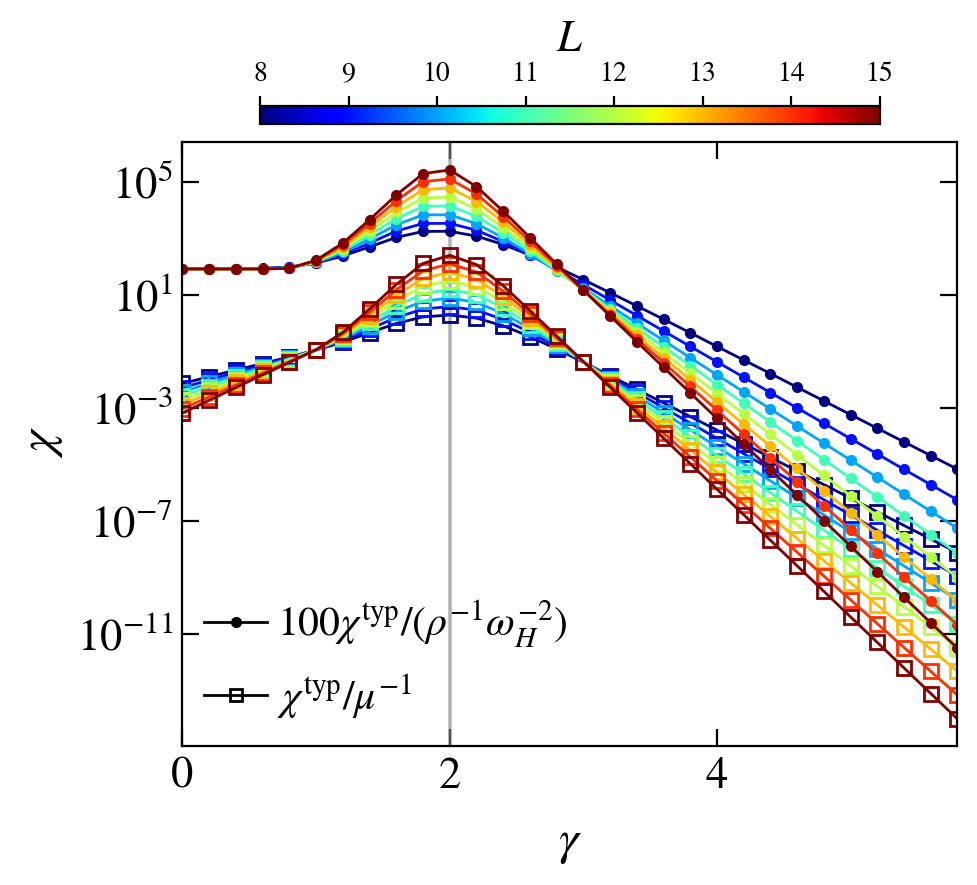

In [54]:
markers_ls2 = ['s','o', 'D', '<', 'X', '^', '*', '+']
markers2 = itertools.cycle(markers_ls2)
colors_ls_cyc = itertools.cycle(colors_ls)
L = 15
w = 2
J = 1
g = 1.5
op=0
modello = 'RP'
prefix = base_dir(model=modello, d=DIM) + 'SpectralFunctions2/'

DIM = 1
g_crit = 2

window = 3

gamma_vals = np.arange(0.0, 6.0, 0.2)



dim = 2**L
sizes = np.arange(8, 16, 1)

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])


fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200)

agp_max = []
alfa_max1 = []
susc_max = []
alfa_max2 = []
for L in sizes:
    col = s_m.to_rgba(L)
    dim = 2**(L)
    
    reals    = np.zeros((gamma_vals.size)); reals.fill(np.nan)
    agp      = np.zeros((gamma_vals.size)); agp.fill(np.nan)
    susc     = np.zeros((gamma_vals.size)); susc.fill(np.nan)
    typ_susc = np.zeros((gamma_vals.size)); typ_susc.fill(np.nan)
    norm_av = np.zeros((gamma_vals.size)); norm_av.fill(np.nan)
    norm_typ = np.zeros((gamma_vals.size)); norm_typ.fill(np.nan)
    wH = np.zeros((gamma_vals.size)); wH.fill(np.nan)
    wH_anal = np.zeros((gamma_vals.size)); wH_anal.fill(np.nan)
    
    susc_GS      = np.zeros((gamma_vals.size)); susc_GS.fill(np.nan)
    susc_r_GS    = np.zeros((gamma_vals.size)); susc_r_GS.fill(np.nan)
    for ii, gx in enumerate(gamma_vals):
        eta = 2 / (2 - gx) if gx >= 1 else 2
        if gx > 2: eta = 2 / (gx - 2)
        name = prefix +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        
        if exists(name):
            with h5py.File(name, "r") as file:
                susc_GS[ii] = np.array(file.get('susc'))[-1]
                susc_r_GS[ii] = np.array(file.get('susc_r'))[-1]
                R = np.array(file.get('realisations'))
                # DOS = dim
                
                wHx = np.array(file.get('wH'))[-2]
                wHx_typ = np.array(file.get('wH_typ'))[-2]
                wH[ii] = wHx_typ
                # wHx = 1/dim
                DOS = max(np.array(file.get('DOS')))
                # DOS = np.sum(DOS[DOS.size//4 : 3 * DOS.size//4])
                # DOS = 1 / wHx
                # norm1[ii] = (DOS)**(-2 / eta) / wHx_typ**2 #if gx <= g_crit else 1 / wHx_typ**2
                # norm2[ii] = DOS**(-1) * wHx_typ**(-2)
                
                # DOS = max(np.array(file.get('DOS'))) / R
                # norm2[ii] = DOS**(-2 / eta) / wHx**2 if alfa >= alfa_crit else 1 / wHx**2
                
                reals[ii] = np.array(file.get('realisations'))
                agp[ii] = np.array(file.get('SUSC_R'))[0] * 10**0
                # print(agp)
                susc[ii] = np.array(file.get('SUSC_R'))[0]
                typ_susc[ii] = np.array(file.get('TYP_SUSC'))[0]
                norm_av[ii] = 1 / wHx
                norm_typ[ii] = DOS**(-1) * wHx_typ**(-2)
        else:
            print(name)

    
    print(L, "REAL:", np.min(reals), np.max(reals))
    
    # indices = np.argwhere(gamma_vals < g_crit)
    # axis.plot(gamma_vals, typ_susc / dim**(2 - np.abs(2 - gamma_vals) ), color=col, marker='o', markersize=3, lw=1)
    axis.plot(gamma_vals, 100*typ_susc/norm_typ, color=col, marker='o', markersize=3, lw=1)
    axis.axvline(x = 2 * 15 / L * np.log2(10), color=col, ls='--')
    
    # axis.plot(gamma_vals, typ_susc, color=col, marker='o', markersize=3, lw=1)
    # axis.plot(gamma_vals, agp / typ_susc, color=col, marker='s', markersize=5, lw=1, markerfacecolor='None')
    
    # indices = np.argwhere(gamma_vals >= g_crit)
    # axis.plot(gamma_vals, typ_susc / dim**(4-gamma_vals), color=col, marker='s', markersize=3, lw=1, markerfacecolor='None')
    axis.plot(gamma_vals, agp / norm_av   , color=col, marker='s', markersize=5, lw=1, markerfacecolor='None')
axis.plot(np.nan, np.nan, color='k', marker='o', markersize=3, lw=1, label=r"$100\chi^{\rm typ}/(\rho^{-1}\omega_H^{-2})$")
axis.plot(np.nan, np.nan, color='k', marker='s', markersize=4, lw=1, markerfacecolor='None', label=r"$\chi^{\rm typ}/\mu^{-1}$") 
    
# fig.subplots_adjust(top=0.97)
cbar_ax = axis.inset_axes([0.1, 1.03, 0.8, 0.03])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
cbar.set_label(r"$L$", fontsize=16)
cbar_ax.xaxis.set_ticks_position('top')
cbar_ax.xaxis.set_label_position('top')

axis.set_xlim(min(gamma_vals), max(gamma_vals))

axis.axvspan(xmin = g_crit - 0.005, xmax = g_crit + 0.005, color='gray', alpha=0.5 )

# fig_help.set_plot_elements(axis, ylabel=r" $\chi\cdot D^{|\gamma-2|-2}$", xlabel=r"$\gamma$", font_size=16, set_legend=False, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis, ylabel=r" $\chi$", xlabel=r"$\gamma$", font_size=16, set_legend=False, xscale='linear', yscale='log')
fig_help.set_legend(axis, fontsize=15, loc='lower left')

fig.subplots_adjust(wspace = 0.03, hspace=0.03)
# fig.savefig("plots_AGP/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)

8 SzL REAL: 6000.0 6000.0 [6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000.
 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000.
 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000.]
8 Sz1_SzL REAL: 6000.0 6000.0 [6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000.
 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000.
 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000.]
9 SzL REAL: 6000.0 6000.0 [6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000.
 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000.
 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000.]
9 Sz1_SzL REAL: 6000.0 6000.0 [6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000.
 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000.
 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000. 6000.]
10 SzL R

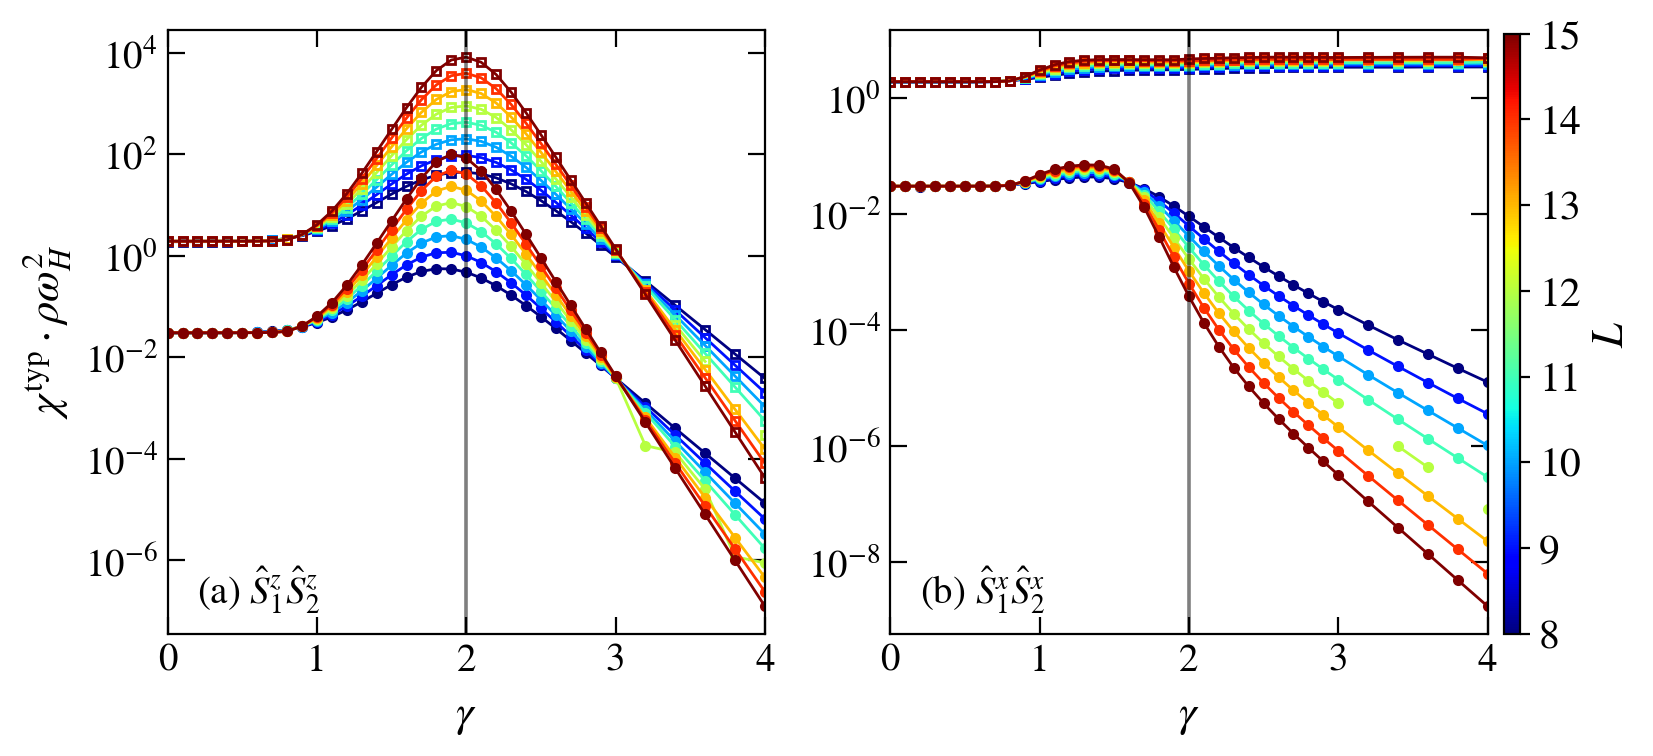

In [56]:
markers_ls2 = ['s','o', 'D', '<', 'X', '^', '*', '+']
markers2 = itertools.cycle(markers_ls2)
colors_ls_cyc = itertools.cycle(colors_ls)
L = 15
w = 2
J = 1
g = 1.5
op=0
modello = 'RP'

DIM = 1
g_crit = 2

window = 3

# gamma_vals = np.arange(0.0, 4.01, 0.1)
gamma_vals = np.array( [*np.arange(0.0, 2.99, 0.1), *np.arange(3.0, 4.01, 0.2)] )

TYPICAL = 0
fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8,4), dpi = 200)
axis = axis.flatten()
    
for ii_typ, TYPICAL in enumerate([0, 1]):
    dim = 2**L
    sizes = np.arange(8, 16, 1)

    norm = matplotlib.colors.Normalize(
            vmin=min(sizes),
            vmax=max(sizes) )

    # create a ScalarMappable and initialize a data structure
    s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
    s_m.set_array([])
    

    # _operators_ = ["Sz1_SzL", "Sz1_SzL", "Sx_L2", "Sx1_SxL", "Sparse_Random"]
    # _operators_latex = [r"$\hat{S}^z_L$", r"$\hat{S}^z_1\hat{S}^z_L$", r"$\hat{S}^z_1\hat{S}^z_L$", r"$\hat{S}^x_{L/2}$", r"$\hat{S}^x_1\hat{S}^x_L$", r"$\hat{R}_{\rm sp}$"]
    
    _operators_ = ["Sz1_SzL", "Sx1_SxL"]
    _operators_latex = [r"$\hat{S}^z_1\hat{S}^z_2$", r"$\hat{S}^x_1\hat{S}^x_2$"]
    _indices = [0, 1] # +1 cause of Sz_L
    
    for L in sizes:
        col = s_m.to_rgba(L)
        dim = float(2**(L))
        
        reals    = np.zeros((6, gamma_vals.size)); reals.fill(np.nan)
        typ_susc = np.zeros((6, gamma_vals.size)); typ_susc.fill(np.nan)
        norm = np.zeros((gamma_vals.size)); norm.fill(np.nan)
        for ii, gx in enumerate(gamma_vals):
            eta = 2 / np.abs(2 - gx) if gx >= 1 else 2
            
            prefix = base_dir(model=modello, d=DIM) + 'SpectralFunctions/'
            name = prefix +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
            
            if not exists(name):
                name = base_dir(model=modello, d=DIM) + 'SpectralFunctions2/' +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
            if exists(name):
                try:
                    with h5py.File(name, "r") as file:
                        wHx = np.array(file.get('wH'))[-2]
                        wHx_typ = np.array(file.get('wH_typ'))[-2]
                        # wH[ii] = wHx
                        DOS = max(np.array(file.get('DOS')))
                        # DOS = 1/wHx
                        mu = np.sqrt(L) / dim
                        # norm[ii] = DOS**(-1) * (mu)**(-2) if not TYPICAL else DOS**(-1) * wHx_typ**(-2)#DOS**(-1) * (np.sqrt(L) / dim)**(-2)
                        norm[ii] = DOS**(-1) * (wHx)**(-2) if not TYPICAL else DOS**(-1) * wHx_typ**(-2)#DOS**(-1) * (np.sqrt(L) / dim)**(-2)
                        # norm[ii] = (wHx)**(-1) if gx >= 1 else 1 / mu
                        # norm[ii] = DOS**(-1) * wHx**(-2) if gx >= 1 else DOS**(-1) * (np.sqrt(L) / dim)**(-2)
                        
                        reals[0, ii] = np.array(file.get('realisations'))
                        if TYPICAL: typ_susc[0, ii] = np.array(file.get('TYP_SUSC'))[-2]
                        # else:       typ_susc[0, ii] = np.array(file.get('SUSC_R'))[-2]
                except OSError:
                    print("CORRUPTED FILE", name)
            else:
                print(name)
            # # prefix = base_dir(model=modello, d=DIM) + 'SpectralFunctions/OtherOperators_mu=sqrt(L)_D/'
            prefix = base_dir(model=modello, d=DIM) + 'SpectralFunctions/OtherOperators/'
            name = prefix +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
            
            if exists(name):
                try:
                    with h5py.File(name, "r") as file:
                        for iiop, opname in enumerate(_operators_):
                            reals[iiop, ii] = np.array(file.get(opname + '/realisations'))
                            
                            # wHx = np.array(file.get(opname + '/wH'))[-2]
                            # wHx_typ = np.array(file.get(opname + '/wH_typ'))[-2]
                            # norm[ii] = dim**(-1) * (wHx)**(-2) if not TYPICAL else dim**(-1) * wHx_typ**(-2)#DOS**(-1) * (np.sqrt(L) / dim)**(-2)
                            if TYPICAL: typ_susc[iiop, ii] = np.array(file.get(opname + '/TYP_SUSC'))[-2]
                            else:       typ_susc[iiop, ii] = np.array(file.get(opname + '/SUSC_R'))[-2]
                except (OSError, TypeError):
                    print("CORRUPTED FILE", name)
            else:
                print(name)

        # for iiop in range( len(_operators_) + 1):
        for iiop in _indices:
            print(L, _operators_[iiop-1] if iiop > 0 else "SzL", "REAL:", np.min(reals[iiop]), np.max(reals[iiop]), reals[iiop])
            axis[iiop].plot(gamma_vals, typ_susc[iiop] / norm * 0.01**ii_typ, color=col, marker='o' if ii_typ else 's', markersize=3, lw=1, markerfacecolor=col if ii_typ else 'None')
        

labs = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
# for iiop in range( len(_operators_) + 1):
for ii, iiop in enumerate(_indices):
    ylab = r"$\chi^{\rm typ}\cdot\rho\omega_H^2$" if TYPICAL else r"$\chi^{\rm av}\cdot\rho\omega_H^2$"
    # ylab = r"$\chi^{\rm typ}\cdot\mu$" if TYPICAL else r"$\chi^{\rm av}\cdot\mu$"
    # ylab = r"$\chi^{\rm typ}$" if TYPICAL else r"$\chi^{\rm av}$"
    # ylab = r"$\overline{|O_{nm}|^2}(\omega,\epsilon)$" if AGP else r"$\overline{|O_{nm}|^2}^{\rm typ}(\omega,\epsilon)$"
    fig_help.set_plot_elements(axis[ii], ylabel=ylab if ii==0 else "", xlabel=r"$\gamma$", font_size=14, set_legend=False, xscale='linear', yscale='log' if iiop < 3 else 'log')
    axis[ii].annotate(labs[ii] + " " + _operators_latex[iiop], fontsize=14, xy=(0.05, 0.05), xycoords='axes fraction')    
    axis[ii].set_xlim(0.0, 4)
    axis[ii].axvline(x=g_crit, ls='-', c='k', alpha=0.5, lw=1.3)
    
fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.125, 0.01, 0.75])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='vertical')
cbar.set_label(r"$L$", fontsize=16)
cbar.ax.tick_params(labelsize=15)


fig.subplots_adjust(wspace = 0.21, hspace=0.21)
    
    # fig.savefig("plots_AGP/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)

## REAL DATA

[0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2. ]


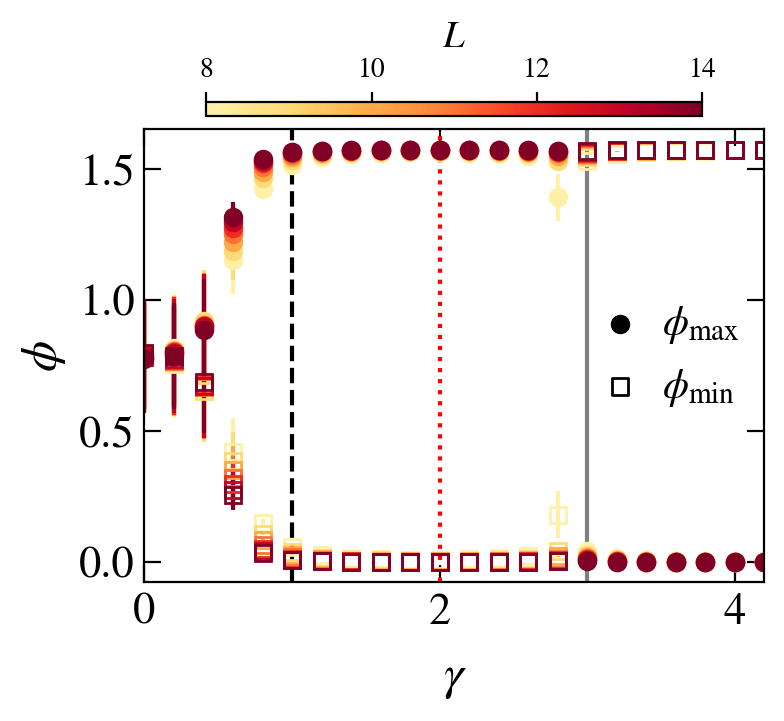

In [11]:
L = 14
w = 2
J = 1
g = 1.5
op=0
modello = 'RP'
# prefix = base_dir(model=modello, d=DIM) + 'GOE/GeometricTensor/realisation=0/'

sizes = np.arange(8, 15, 1)

DIM = 1
g_crit = 2

window = 3

gamma_vals = np.arange(0.0, 5.01, 0.2)
gamma_plot = np.round(np.arange(0.9, 2.01, 0.1), 2)
print(gamma_plot)


dim = 2**L
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200)

norm = matplotlib.colors.Normalize(
                vmin=min(sizes),
                vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
# s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

for L in sizes:
    col = s_m.to_rgba(L)
    dim = 2**L
    for ii, gx in enumerate(gamma_vals):
        alfa = np.round(gx, 2)
        eta = 2 / (2 - gx)
        prefix = base_dir(model=modello, d=DIM) + 'GOE/GeometricTensor2/'
        name = prefix +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name):
            with h5py.File(name, "r") as file:
                phi_max = np.abs(np.array(file.get('phi_max_av')))
                phi_min = np.abs(np.array(file.get('phi_min_av')))
                phi_max_sig = np.abs(np.array(file.get('phi_max_var')))
                phi_min_sig = np.abs(np.array(file.get('phi_min_var')))
                # axis.scatter(gx, phi_max, color = 'blue', marker = 'o', alpha=0.5)
                # axis.scatter(gx, phi_min, color = 'red', facecolor='None', marker = 's', alpha=0.5)
                axis.errorbar(gx, phi_max,  yerr=phi_max_sig, fmt='o',  color=col)
                axis.errorbar(gx, phi_min,  yerr=phi_min_sig, fmt='s',  color=col, markerfacecolor='none')
        else:
            print(name)

axis.scatter(np.nan, np.nan, color = 'k', marker = 'o', label=r"$\phi_{\rm max}$")
axis.scatter(np.nan, np.nan, color = 'k', facecolor='None',marker = 's', label=r"$\phi_{\rm min}$")
    
axis.axvline(x=1,    ls='--', c='k')
axis.axvline(x=2,    ls=':', c='red')
axis.axvline(x=3,    ls='-', c='gray')
axis.set_xlim(0, 4.2)

 
# fig.subplots_adjust(top=0.97)
cbar_ax = axis.inset_axes([0.1, 1.03, 0.8, 0.03])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
cbar.set_label(r"$L$", fontsize=14)
cbar_ax.xaxis.set_ticks_position('top')
cbar_ax.xaxis.set_label_position('top')

ylab = r"$\phi$"# if projected else r"$||\mathcal{A}_\lambda(\epsilon)||^2$"
fig_help.set_plot_elements(axis, ylabel=ylab, xlabel=r"$\gamma$", font_size=16, set_legend=True, xscale='linear', yscale='linear')
fig_help.set_legend(axis, fontsize=15, loc='center right', ncol = 1, columnspacing=0.6)
fig.savefig("../../QuantumSun/Jupyter_Python/plots_LOC_RES/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)

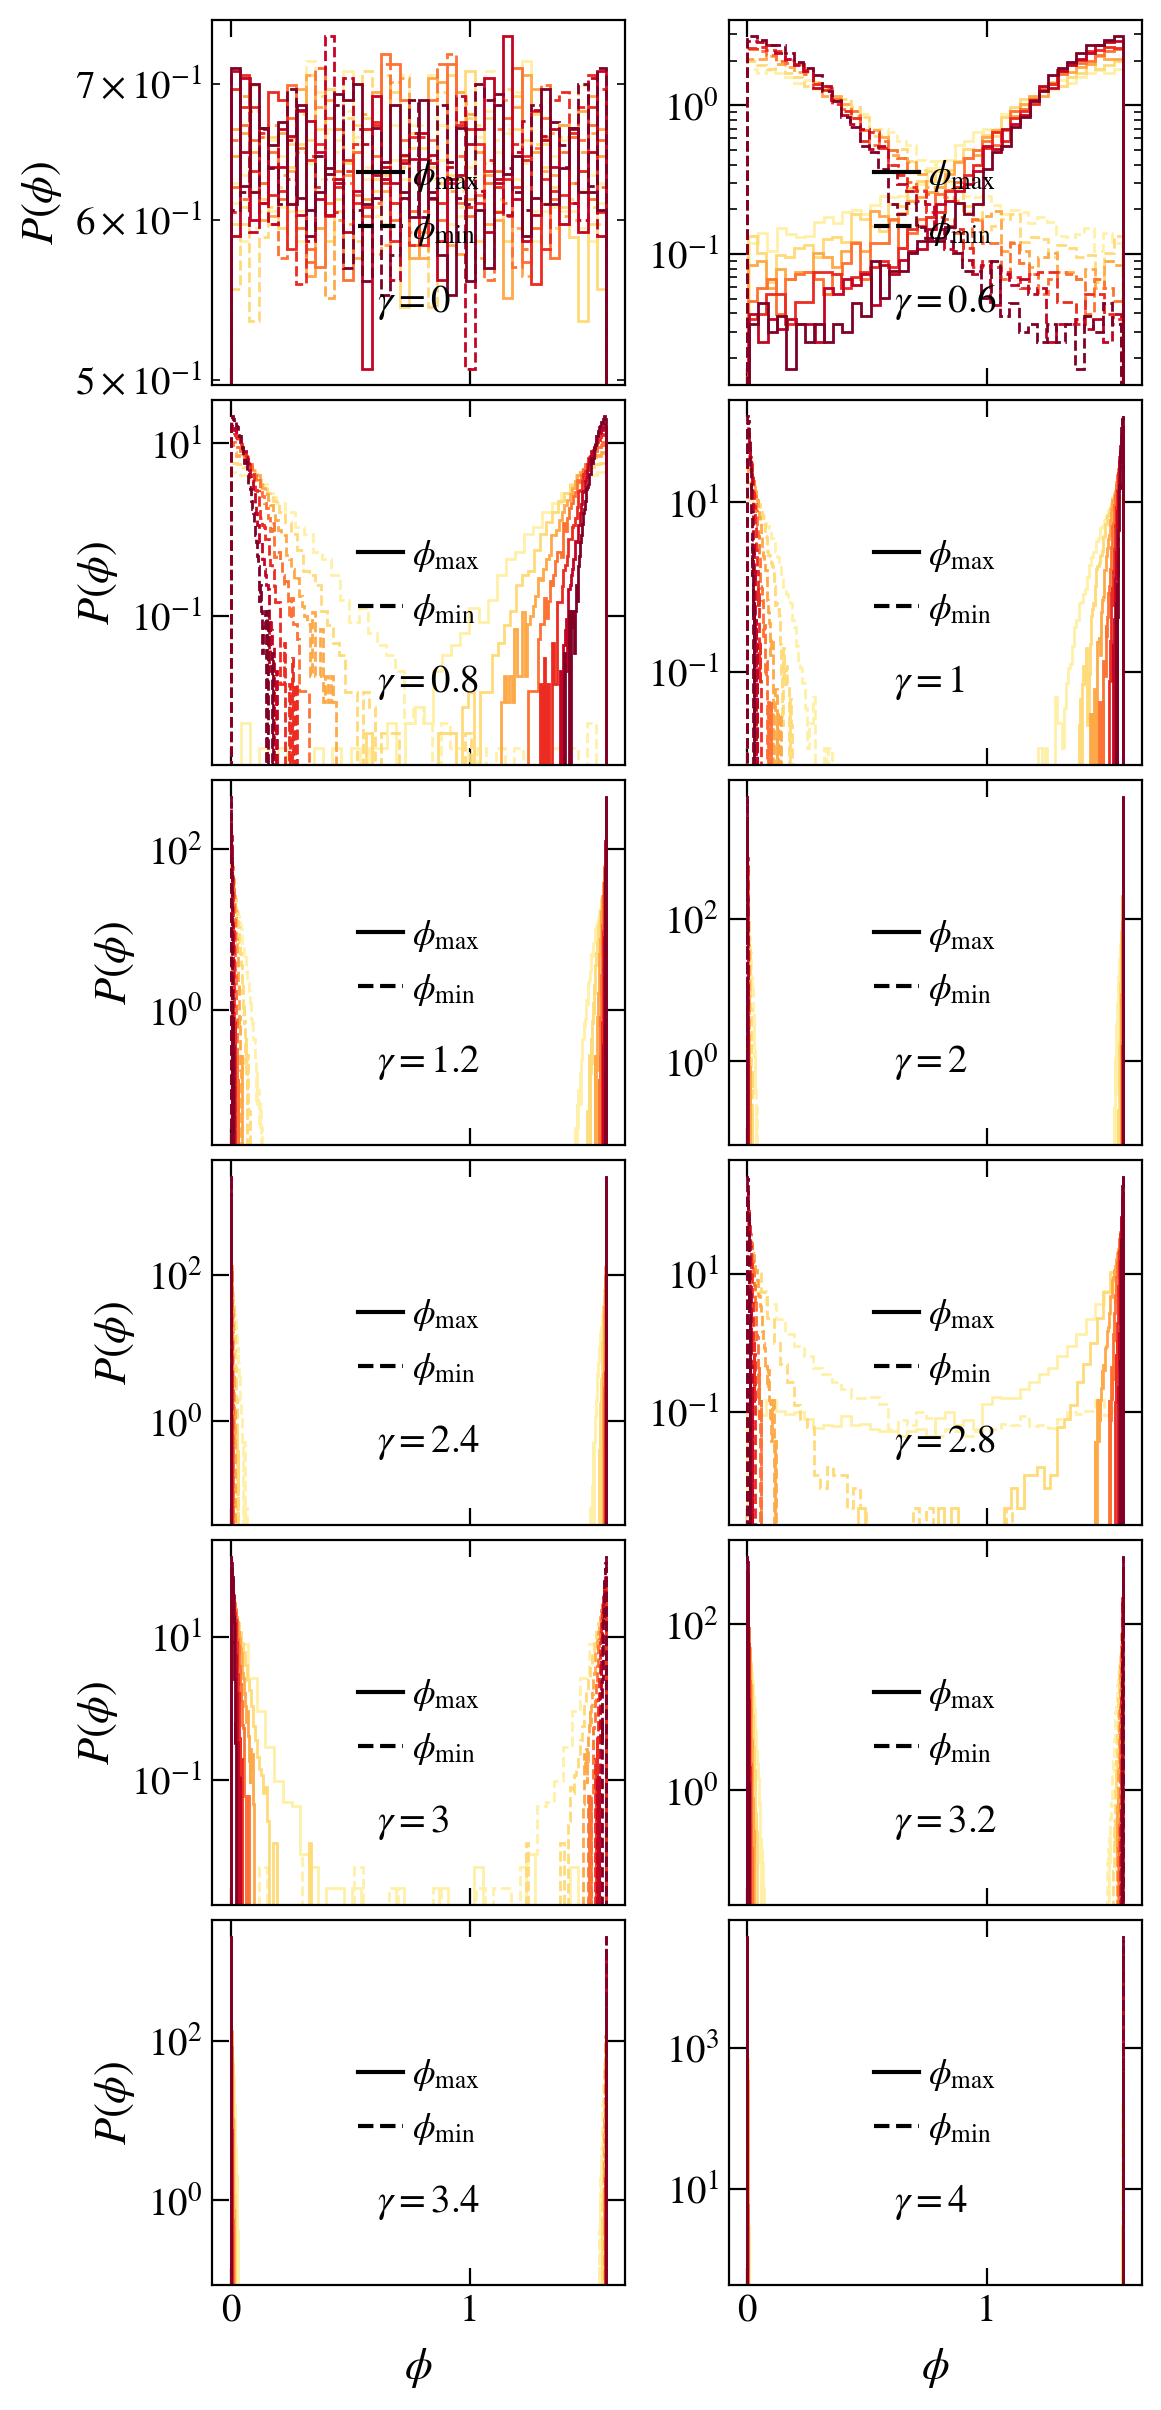

In [7]:
L = 14
w = 2
J = 1
g = 1.5
op=0
modello = 'RP'
# prefix = base_dir(model=modello, d=DIM) + 'GOE/GeometricTensor/realisation=0/'

sizes = np.arange(8, 15, 1)

DIM = 1
g_crit = 2

window = 3

gamma_vals = np.array([0.0, 0.6, 0.8, 1.0, 1.2, 2.0, 2.4, 2.8, 3.0, 3.2, 3.4, 4.0])



fig, axis = plt.subplots( nrows=gamma_vals.size//2, ncols=2, figsize=(6,2.5*gamma_vals.size//2), dpi = 200, sharex = True)
axis = axis.flatten()

norm = matplotlib.colors.Normalize(
                vmin=min(sizes),
                vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
# s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

for L in sizes:
    col = s_m.to_rgba(L)
    dim = 2**L
    for ii, gx in enumerate(gamma_vals):
        alfa = np.round(gx, 2)
        eta = 2 / (2 - gx)
        prefix = base_dir(model=modello, d=DIM) + 'GOE/GeometricTensor2/'
        name = prefix +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name):
            with h5py.File(name, "r") as file:
                dist = np.abs(np.array(file.get('phi_max_hist')))
                edge = np.abs(np.array(file.get('phi_max_bins')))
                axis[ii].stairs(dist, edge, color=col)
                # axis[ii].plot(edge, dist, color='blue')
                
                dist = np.abs(np.array(file.get('phi_min_hist')))
                edge = np.abs(np.array(file.get('phi_min_bins')))
                axis[ii].stairs(dist, edge, color=col, ls='--')
                
        else:
            print(name)

        if L == sizes[0]:
            axis[ii].plot(np.nan, np.nan, color = 'k', label=r"$\phi_{\rm max}$")
            axis[ii].plot(np.nan, np.nan, color = 'k', ls='--', label=r"$\phi_{\rm min}$")
            axis[ii].annotate(r"$\gamma=%g$"%gx, fontsize=14, xy=(0.4, 0.2), xycoords='axes fraction')
    
        ylab = r"$P(\phi)$" if ii%2==0 else ""
        fig_help.set_plot_elements(axis[ii], ylabel=ylab, xlabel=r"$\phi$" if ii > len(axis)-3 else "", font_size=14, set_legend=True, xscale='linear', yscale='log')
        fig_help.set_legend(axis[ii], fontsize=13, loc='center', ncol = 1, columnspacing=0.6)
        
fig.subplots_adjust(wspace = 0.25, hspace=0.04)

fig.savefig("../../QuantumSun/Jupyter_Python/plots_LOC_RES/Fig4.pdf", bbox_inches = 'tight', pad_inches=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


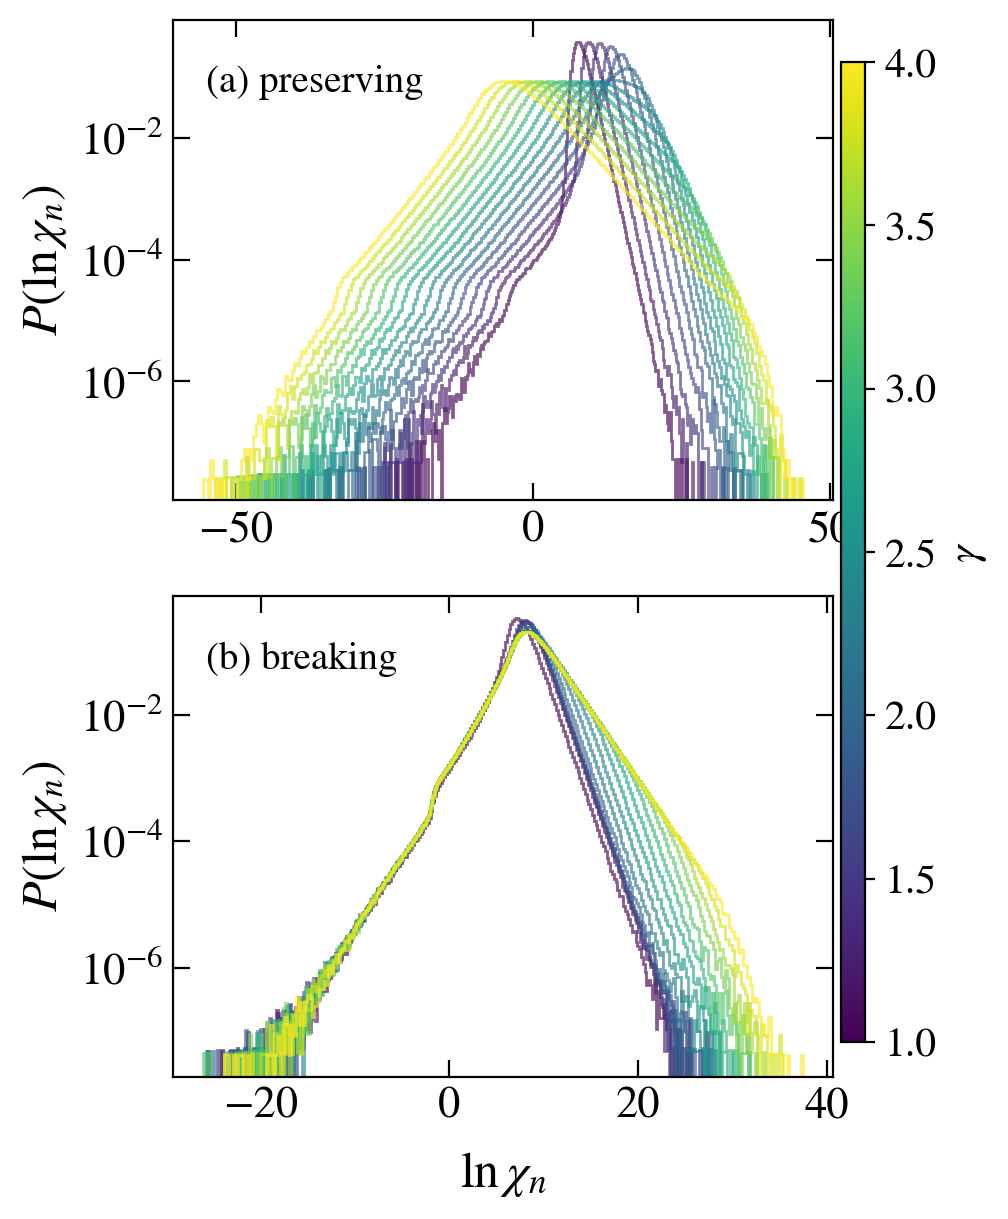

In [29]:
L = 14
w = 2
J = 1
g = 1.5
op=0
modello = 'RP'
# prefix = base_dir(model=modello, d=DIM) + 'GOE/GeometricTensor/realisation=0/'

sizes = np.arange(8, 15, 1)

DIM = 1
g_crit = 2

window = 3

gamma_vals = np.arange(1.0, 4.01, 0.2)

norm = matplotlib.colors.Normalize(
        vmin=min(gamma_vals),
        vmax=max(gamma_vals) )

# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

dim = 2**L
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,7), dpi = 200)

for ii, gx in enumerate(gamma_vals):
    col = s_m.to_rgba(gx)
    prefix = base_dir(model=modello, d=DIM) + 'GOE/GeometricTensor2/'
    name = prefix +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
    if exists(name):
        with h5py.File(name, "r") as file:
            dist = np.array(file.get('chi_Sz/dist'))
            edge = np.array(file.get('chi_Sz/edge'))
            axis[0].stairs(dist, edge, color=col, alpha=0.65)
            idx = np.argmax(dist)
            pars, pconv= fit(exp_fit,
                        xdata = edge[idx + 11:-2],
                        ydata = dist[idx + 10:-2],
                        maxfev = 20000)
            # axis[0].plot(edge[idx + 11:-2], exp_fit(edge[idx + 11:-2], *pars), lw=2, ls='--', color=col)
            
            dist = np.array(file.get('chi_Sx/dist'))
            edge = np.array(file.get('chi_Sx/edge'))
            axis[1].stairs(dist, edge, color=col, alpha=0.65)
            idx = np.argmax(dist)
            pars, pconv= fit(exp_fit,
                        xdata = edge[idx + 11:-2],
                        ydata = dist[idx + 10:-2],
                        maxfev = 20000)
            # axis[1].plot(edge[idx + 11:-2], exp_fit(edge[idx + 11:-2], *pars), lw=2, ls='--', color=col)
    else:
        print(name)

axis[0].annotate(r"(a) preserving", fontsize=14, xy=(0.05, 0.85), xycoords='axes fraction')
axis[1].annotate(r"(b) breaking", fontsize=14, xy=(0.05, 0.85), xycoords='axes fraction')
    
ylab = r"$P(\ln\chi_n)$"
fig_help.set_plot_elements(axis[0], ylabel=ylab, xlabel="", font_size=16, set_legend=True, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=ylab, xlabel=r"$\ln\chi_n$", font_size=16, set_legend=True, xscale='linear', yscale='log')
# fig_help.set_legend(axis, fontsize=15, loc='center right', ncol = 1, columnspacing=0.6)

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.03, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$\gamma$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

fig.savefig("../../QuantumSun/Jupyter_Python/plots_LOC_RES/FigA3.pdf", bbox_inches = 'tight', pad_inches=0.02)

No handles with labels found to put in legend.


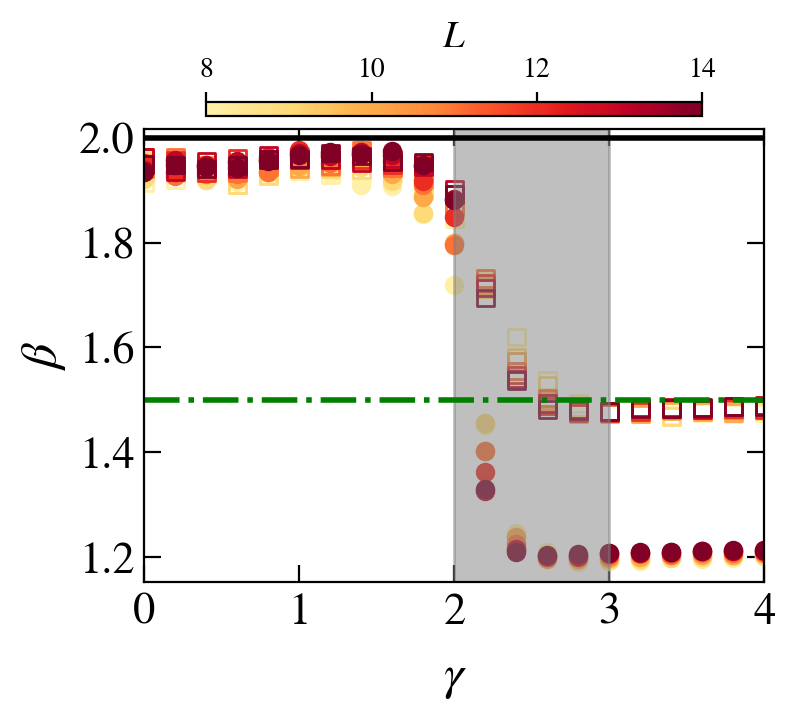

In [26]:
L = 14
w = 2
J = 1
g = 1.5
op=0
modello = 'RP'
# prefix = base_dir(model=modello, d=DIM) + 'GOE/GeometricTensor/realisation=0/'

sizes = np.arange(8, 15, 1)

DIM = 1
g_crit = 2

window = 3

gamma_vals = np.arange(0.0, 4.01, 0.2)


norm = matplotlib.colors.Normalize(
                vmin=min(sizes),
                vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200)
for L in sizes:
    col = s_m.to_rgba(L)
    
    dim = 2**L

    def exp_fit(x, mu, a):
        return a * np.exp(- x * mu)

    Sz_exp = np.zeros(gamma_vals.shape)
    Sx_exp = np.zeros(gamma_vals.shape)
    for ii, gx in enumerate(gamma_vals):
        # col = s_m.to_rgba(gx)
        prefix = base_dir(model=modello, d=DIM) + 'GOE/GeometricTensor2/'
        name = prefix +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name):
            with h5py.File(name, "r") as file:
                dist = np.array(file.get('chi_Sz/dist'))
                edge = np.array(file.get('chi_Sz/edge'))
                idx = np.argmax(dist)
                pars, pconv= fit(exp_fit,
                            xdata = edge[idx + 11:-20],
                            ydata = dist[idx + 10:-20],
                            maxfev = 20000)
                Sz_exp[ii] = 1+pars[0]
                
                dist = np.array(file.get('chi_Sx/dist'))
                edge = np.array(file.get('chi_Sx/edge'))
                idx = np.argmax(dist)
                pars, pconv= fit(exp_fit,
                            xdata = edge[idx + 11:-20],
                            ydata = dist[idx + 10:-20],
                            maxfev = 20000)
                Sx_exp[ii] = 1+pars[0]
        else:
            print(name)
        
    axis.scatter(gamma_vals, Sz_exp, marker='o', color=col)
    axis.scatter(gamma_vals, Sx_exp, marker='s', color=col, facecolor='None')
axis.axvspan(xmin=2, xmax=3, color='gray', alpha=0.5)

axis.axhline(y=2, ls='-', color='k', lw=2)
axis.axhline(y=1.5, ls='-.', color='green', lw=2)
cbar_ax = axis.inset_axes([0.1, 1.03, 0.8, 0.03])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
cbar.set_label(r"$L$", fontsize=14)
cbar_ax.xaxis.set_ticks_position('top')
cbar_ax.xaxis.set_label_position('top')

axis.set_xlim(0, 4)

fig_help.set_plot_elements(axis, ylabel=r"$\beta$", xlabel="$\gamma$", font_size=16, set_legend=True, xscale='linear', yscale='linear')
# fig_help.set_legend(axis, fontsize=15, loc='center right', ncol = 1, columnspacing=0.6)
fig.savefig("../../QuantumSun/Jupyter_Python/plots_LOC_RES/Fig6.pdf", bbox_inches = 'tight', pad_inches=0.02)

8 REAL: 9000.0 9000.0
9 REAL: 9000.0 9000.0
10 REAL: 9000.0 9000.0
11 REAL: 9000.0 9000.0
12 REAL: 9000.0 9000.0
13 REAL: 9000.0 9000.0
14 REAL: 5920.0 6000.0


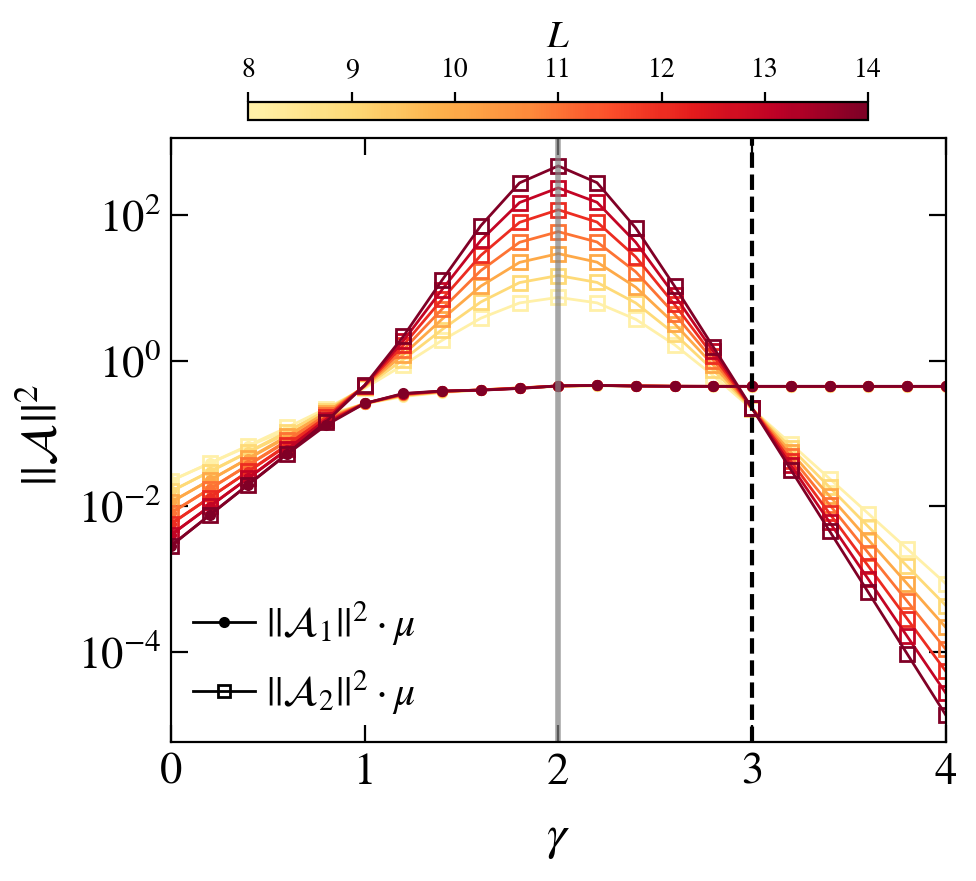

In [2]:
markers_ls2 = ['s','o', 'D', '<', 'X', '^', '*', '+']
markers2 = itertools.cycle(markers_ls2)
colors_ls_cyc = itertools.cycle(colors_ls)
L = 15
w = 2
J = 1
g = 1.5
op=0
modello = 'RP'
prefix2 = base_dir(model=modello, d=DIM) + 'SpectralFunctions2/'
prefix = base_dir(model=modello, d=DIM) + 'GOE/GeometricTensor2/'

DIM = 1
g_crit = 2

window = 3

gamma_vals = np.arange(0.0, 4.1, 0.2)



dim = 2**L
sizes = np.arange(8, 15, 1)


norm = matplotlib.colors.Normalize(
                vmin=min(sizes),
                vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])


fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200)

agp_max = []
alfa_max1 = []
susc_max = []
alfa_max2 = []
for L in sizes:
    col = s_m.to_rgba(L)
    dim = 2**(L)
    
    reals    = np.zeros((gamma_vals.size)); reals.fill(np.nan)
    agp      = np.zeros((gamma_vals.size)); agp.fill(np.nan)
    susc     = np.zeros((gamma_vals.size)); susc.fill(np.nan)
    typ_susc = np.zeros((gamma_vals.size)); typ_susc.fill(np.nan)
    norm_av = np.zeros((gamma_vals.size)); norm_av.fill(np.nan)
    norm_typ = np.zeros((gamma_vals.size)); norm_typ.fill(np.nan)
    wH = np.zeros((gamma_vals.size)); wH.fill(np.nan)
    wH_anal = np.zeros((gamma_vals.size)); wH_anal.fill(np.nan)
    
    susc_GS      = np.zeros((gamma_vals.size)); susc_GS.fill(np.nan)
    susc_r_GS    = np.zeros((gamma_vals.size)); susc_r_GS.fill(np.nan)
    for ii, gx in enumerate(gamma_vals):
        eta = 2 / (2 - gx) if gx >= 1 else 2
        if gx > 2: eta = 2 / (gx - 2)
        name = prefix2 +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name):
            with h5py.File(name, "r") as file:
                wHx = np.array(file.get('wH'))[-2]
                wHx_typ = np.array(file.get('wH_typ'))[-2]
                wH[ii] = wHx_typ
                DOS = max(np.array(file.get('DOS')))
                norm_av[ii] = 1 / wHx
                norm_typ[ii] = DOS**(-1) * wHx_typ**(-2)
        else:
            print(name)
        name = prefix +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name):
            with h5py.File(name, "r") as file:
                reals[ii] = np.array(file.get('realisations'))
                agp[ii] = np.array(file.get('SUSC_R/av'))[0,-1]
                typ_susc[ii] = np.array(file.get('SUSC_R/av'))[1,-1]
                # norm_av[ii] = 1 / wHx
                # norm_typ[ii] = DOS**(-1) * wHx_typ**(-2)
        else:
            print(name)

    
    print(L, "REAL:", np.min(reals), np.max(reals))
    mu = 2 * np.sqrt(1 + dim**(1-gamma_vals)) / dim
    norm = 1/mu
    axis.plot(gamma_vals, typ_susc / norm, color=col, marker='o', markersize=3, lw=1)
    axis.plot(gamma_vals, agp / norm, color=col, marker='s', markersize=5, lw=1, markerfacecolor='None')
# axis.plot(np.nan, np.nan, color='k', marker='o', markersize=3, lw=1, label=r"$\chi^{\rm typ}/(\rho^{-1}\omega_H^{-2})$")
# axis.plot(np.nan, np.nan, color='k', marker='s', markersize=4, lw=1, markerfacecolor='None', label=r"$\chi^{\rm typ}/\mu^{-1}$") 
axis.plot(np.nan, np.nan, color='k', marker='o', markersize=3, lw=1, label=r"$||\mathcal{A}_1||^2\cdot\mu$")
axis.plot(np.nan, np.nan, color='k', marker='s', markersize=4, lw=1, markerfacecolor='None', label=r"$||\mathcal{A}_2||^2\cdot\mu$") 
# fig.subplots_adjust(top=0.97)
cbar_ax = axis.inset_axes([0.1, 1.03, 0.8, 0.03])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
cbar.set_label(r"$L$", fontsize=14)
cbar_ax.xaxis.set_ticks_position('top')
cbar_ax.xaxis.set_label_position('top')

axis.set_xlim(min(gamma_vals), max(gamma_vals))

axis.axvline(x=3, ls='--', color='k')
axis.axvline(x=2, ls='-', color='gray', lw=2, alpha=0.7)
# fig_help.set_plot_elements(axis, ylabel=r" $\chi\cdot D^{|\gamma-2|-2}$", xlabel=r"$\gamma$", font_size=16, set_legend=False, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis, ylabel=r" $||\mathcal{A}||^2$", xlabel=r"$\gamma$", font_size=16, set_legend=False, xscale='linear', yscale='log')
fig_help.set_legend(axis, fontsize=15, loc='lower left')

fig.subplots_adjust(wspace = 0.03, hspace=0.03)
# fig.savefig("plots_AGP/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)
fig.savefig("../../QuantumSun/Jupyter_Python/plots_LOC_RES/Fig4.pdf", bbox_inches = 'tight', pad_inches=0.02)

14 REAL: 5920.0 6000.0
14 REAL: 5920.0 6000.0
14 REAL: 5920.0 6000.0
14 REAL: 5920.0 6000.0
14 REAL: 5920.0 6000.0
14 REAL: 5920.0 6000.0
14 REAL: 5920.0 6000.0


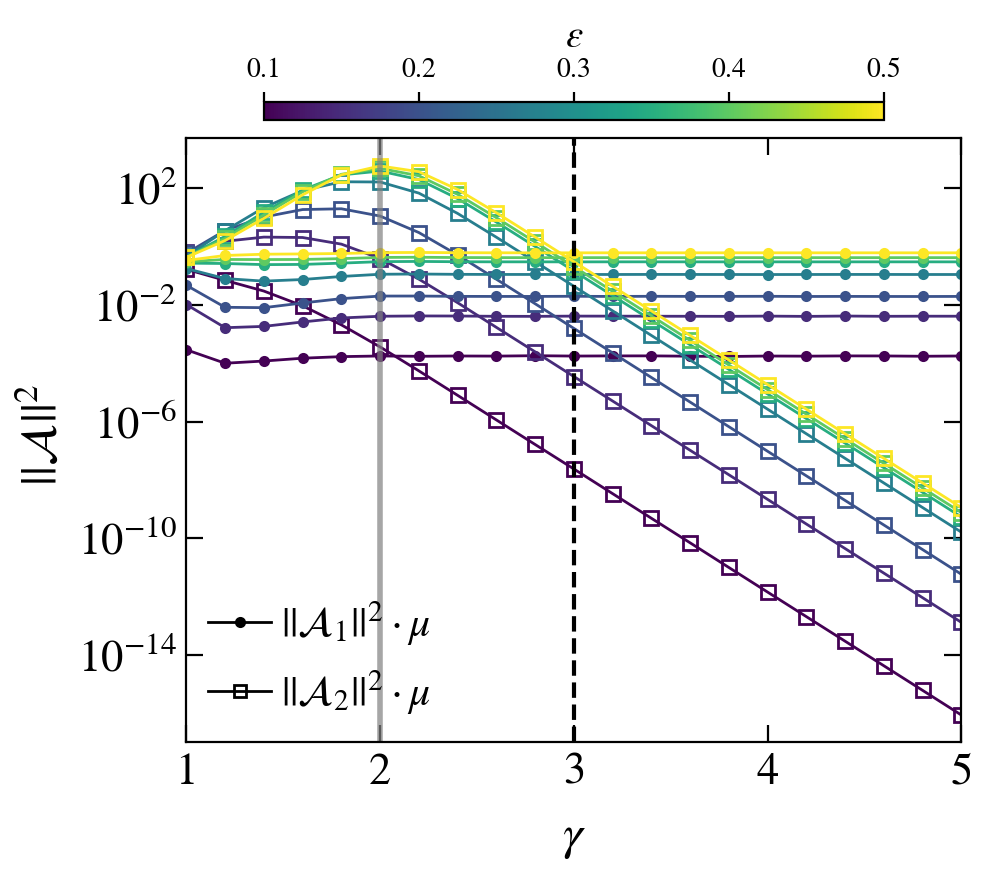

In [7]:
markers_ls2 = ['s','o', 'D', '<', 'X', '^', '*', '+']
markers2 = itertools.cycle(markers_ls2)
colors_ls_cyc = itertools.cycle(colors_ls)
L = 15
w = 2
J = 1
g = 1.5
op=0
modello = 'RP'
prefix2 = base_dir(model=modello, d=DIM) + 'SpectralFunctions2/'
prefix = base_dir(model=modello, d=DIM) + 'GOE/GeometricTensor2/'

DIM = 1
g_crit = 2

window = 3

gamma_vals = np.arange(1.0, 5.1, 0.2)



L=14
dim = 2**L
sizes = np.arange(8, 15, 1)



eps_list = [0.1, 0.15, 0.2, 0.27, 0.35, 0.4, 0.5]
norm = matplotlib.colors.Normalize(
                vmin=min(eps_list),
                vmax=max(eps_list) )

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])


fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200)

EBT = []
FOCK = []
for eps in eps_list:
    col = s_m.to_rgba(eps)
    dim = 2**(L)
    
    reals    = np.zeros((gamma_vals.size)); reals.fill(np.nan)
    agp      = np.zeros((gamma_vals.size)); agp.fill(np.nan)
    susc     = np.zeros((gamma_vals.size)); susc.fill(np.nan)
    typ_susc = np.zeros((gamma_vals.size)); typ_susc.fill(np.nan)
    norm_av = np.zeros((gamma_vals.size)); norm_av.fill(np.nan)
    norm_typ = np.zeros((gamma_vals.size)); norm_typ.fill(np.nan)
    wH = np.zeros((gamma_vals.size)); wH.fill(np.nan)
    wH_anal = np.zeros((gamma_vals.size)); wH_anal.fill(np.nan)
    
    susc_GS      = np.zeros((gamma_vals.size)); susc_GS.fill(np.nan)
    susc_r_GS    = np.zeros((gamma_vals.size)); susc_r_GS.fill(np.nan)
    for ii, gx in enumerate(gamma_vals):
        name = prefix +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name):
            with h5py.File(name, "r") as file:
                reals[ii] = np.array(file.get('realisations'))
                Ex = np.array(file.get('energy_density'))
                idxE = np.argmin( np.abs(Ex - eps) )
                
                agp[ii] = np.array(file.get('SUSC_R_MC/typ_av'))[0,idxE]
                typ_susc[ii] = np.array(file.get('SUSC_R_MC/typ_av'))[1,idxE]
                # norm_av[ii] = 1 / wHx
                # norm_typ[ii] = DOS**(-1) * wHx_typ**(-2)
        else:
            print(name)

    
    print(L, "REAL:", np.min(reals), np.max(reals))
    mu = 2 * np.sqrt(1 + dim**(1-gamma_vals)) / dim
    norm = 1/mu
    axis.plot(gamma_vals, typ_susc / norm, color=col, marker='o', markersize=3, lw=1)
    axis.plot(gamma_vals, agp / norm, color=col, marker='s', markersize=5, lw=1, markerfacecolor='None')
    
    
# axis.plot(np.nan, np.nan, color='k', marker='o', markersize=3, lw=1, label=r"$\chi^{\rm typ}/(\rho^{-1}\omega_H^{-2})$")
# axis.plot(np.nan, np.nan, color='k', marker='s', markersize=4, lw=1, markerfacecolor='None', label=r"$\chi^{\rm typ}/\mu^{-1}$") 
axis.plot(np.nan, np.nan, color='k', marker='o', markersize=3, lw=1, label=r"$||\mathcal{A}_1||^2\cdot\mu$")
axis.plot(np.nan, np.nan, color='k', marker='s', markersize=4, lw=1, markerfacecolor='None', label=r"$||\mathcal{A}_2||^2\cdot\mu$") 
# fig.subplots_adjust(top=0.97)
cbar_ax = axis.inset_axes([0.1, 1.03, 0.8, 0.03])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
cbar.set_label(r"$\epsilon$", fontsize=14)
cbar_ax.xaxis.set_ticks_position('top')
cbar_ax.xaxis.set_label_position('top')

axis.set_xlim(min(gamma_vals), max(gamma_vals))

axis.axvline(x=3, ls='--', color='k')
axis.axvline(x=2, ls='-', color='gray', lw=2, alpha=0.7)
# fig_help.set_plot_elements(axis, ylabel=r" $\chi\cdot D^{|\gamma-2|-2}$", xlabel=r"$\gamma$", font_size=16, set_legend=False, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis, ylabel=r" $||\mathcal{A}||^2$", xlabel=r"$\gamma$", font_size=16, set_legend=False, xscale='linear', yscale='log')
fig_help.set_legend(axis, fontsize=15, loc='lower left')

fig.subplots_adjust(wspace = 0.03, hspace=0.03)
# fig.savefig("plots_AGP/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)
# fig.savefig("../../QuantumSun/Jupyter_Python/plots_LOC_RES/Fig4.pdf", bbox_inches = 'tight', pad_inches=0.02)

14 REAL: 5920.0 6000.0
0.11 4 4
14 REAL: 5920.0 6000.0
0.13 4 4
14 REAL: 5920.0 6000.0
0.15000000000000002 4 4
14 REAL: 5920.0 6000.0
0.17 4 4
14 REAL: 5920.0 6000.0
0.19 4 4
14 REAL: 5920.0 6000.0
0.21000000000000002 4 4
14 REAL: 5920.0 6000.0
0.23000000000000004 4 4
14 REAL: 5920.0 6000.0
0.25 4 4
14 REAL: 5920.0 6000.0
0.27 8 8
14 REAL: 5920.0 6000.0
0.29000000000000004 8 8
14 REAL: 5920.0 6000.0
0.31000000000000005 9 9
14 REAL: 5920.0 6000.0
0.33 9 9
14 REAL: 5920.0 6000.0
0.35000000000000003 9 9
14 REAL: 5920.0 6000.0
0.37000000000000005 9 9
14 REAL: 5920.0 6000.0
0.39 9 9
14 REAL: 5920.0 6000.0
0.41000000000000003 9 9
14 REAL: 5920.0 6000.0
0.43000000000000005 9 9
14 REAL: 5920.0 6000.0
0.45000000000000007 9 9
14 REAL: 5920.0 6000.0
0.4700000000000001 9 9
14 REAL: 5920.0 6000.0
0.49000000000000005 9 9
14 REAL: 5920.0 6000.0
0.5100000000000001 9 9
14 REAL: 5920.0 6000.0
0.5300000000000001 9 9
14 REAL: 5920.0 6000.0
0.55 9 9
14 REAL: 5920.0 6000.0
0.5700000000000001 9 9
14 REAL: 59

No handles with labels found to put in legend.


14 REAL: 5920.0 6000.0
0.7700000000000001 8 8
14 REAL: 5920.0 6000.0
0.7900000000000001 7 7
14 REAL: 5920.0 6000.0
0.8100000000000002 7 7
14 REAL: 5920.0 6000.0
0.8300000000000002 6 6
14 REAL: 5920.0 6000.0
0.8500000000000001 6 6
14 REAL: 5920.0 6000.0
0.8700000000000001 5 5


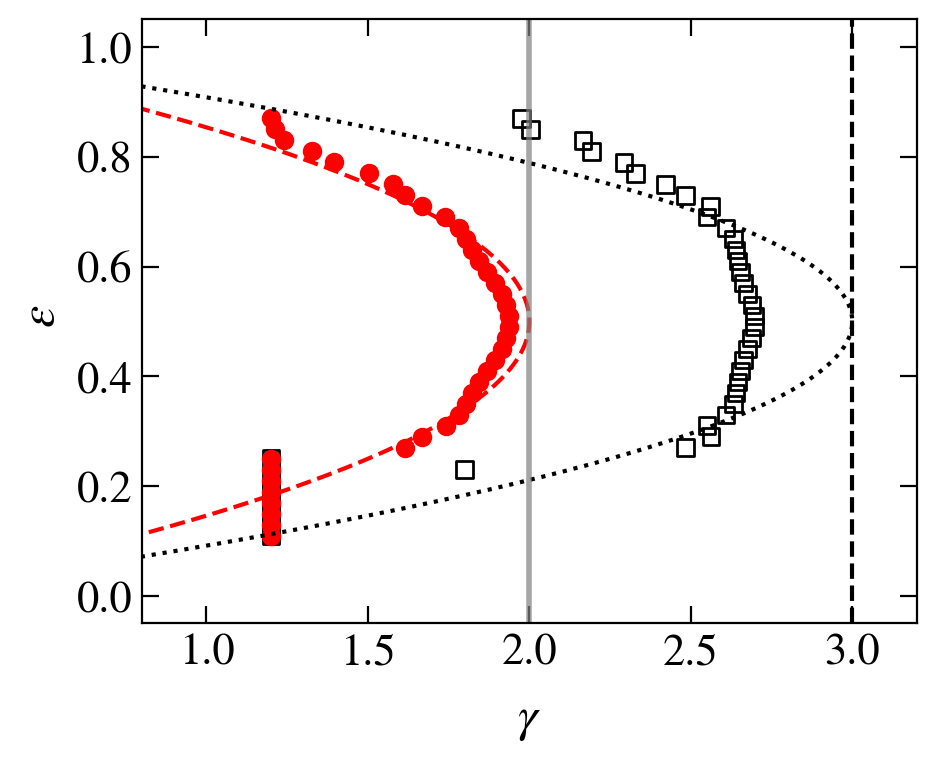

In [11]:
markers_ls2 = ['s','o', 'D', '<', 'X', '^', '*', '+']
markers2 = itertools.cycle(markers_ls2)
colors_ls_cyc = itertools.cycle(colors_ls)
L = 15
w = 2
J = 1
g = 1.5
op=0
modello = 'RP'
prefix2 = base_dir(model=modello, d=DIM) + 'SpectralFunctions2/'
prefix = base_dir(model=modello, d=DIM) + 'GOE/GeometricTensor2/'

DIM = 1
g_crit = 2

window = 3

gamma_vals = np.arange(1.2, 5.1, 0.2)



L=14
dim = 2**L
sizes = np.arange(8, 15, 1)



eps_list = np.arange(0.11, 0.89, 0.02)
norm = matplotlib.colors.Normalize(
                vmin=min(eps_list),
                vmax=max(eps_list) )

s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])


fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200)

EBT = []
FOCK = []
for eps in eps_list:
    col = s_m.to_rgba(eps)
    dim = 2**(L)
    
    reals    = np.zeros((gamma_vals.size)); reals.fill(np.nan)
    agp_pres      = np.zeros((gamma_vals.size)); agp_pres.fill(np.nan)
    agp_break       = np.zeros((gamma_vals.size)); agp_break.fill(np.nan)
    
    susc_GS      = np.zeros((gamma_vals.size)); susc_GS.fill(np.nan)
    susc_r_GS    = np.zeros((gamma_vals.size)); susc_r_GS.fill(np.nan)
    for ii, gx in enumerate(gamma_vals):
        name = prefix +  info(L=L, J=J, g=gx, model=modello, ext='.hdf5')
        if exists(name):
            with h5py.File(name, "r") as file:
                reals[ii] = np.array(file.get('realisations'))
                Ex = np.array(file.get('energy_density'))
                idxE = np.argmin( np.abs(Ex - eps) )
                
                agp_pres[ii] = np.array(file.get('SUSC_R_MC/typ'))[0,idxE]
                agp_break[ii] = np.array(file.get('SUSC_R_MC/typ'))[1,idxE]
                # norm_av[ii] = 1 / wHx
                # norm_typ[ii] = DOS**(-1) * wHx_typ**(-2)
        else:
            print(name)

    
    print(L, "REAL:", np.min(reals), np.max(reals))
    mu = 2 * np.sqrt(1 + dim**(1-gamma_vals)) / dim
    norm = 1/mu
    # axis.plot(gamma_vals, agp_break / norm, color=col, marker='o', markersize=3, lw=1)
    # axis.plot(gamma_vals, agp_pres / norm, color=col, marker='s', markersize=5, lw=1, markerfacecolor='None')
    
    indices = np.argwhere(gamma_vals > 1.4)
    
    idx_fock = np.argmin( np.abs(agp_break[indices] / agp_pres[indices] - 1) )
    indices = np.arange(max(idx_fock - 5,0), min(idx_fock + 4, agp_pres.size-1), 1)
    print(eps, gamma_vals[indices].size, agp_pres[indices].size)
    x = np.linspace(gamma_vals[indices][0], gamma_vals[indices][-1], 1000)
    f1 = splrep(gamma_vals[indices], agp_pres[indices], k=3, s=1)
    f2 = splrep(gamma_vals[indices], agp_break[indices], k=3, s=1)
    agp_pres_interpolated = splev(x, f1)
    agp_break_interpolated = splev(x, f2)
    idx_fock = np.argmin( np.abs(agp_break_interpolated / agp_pres_interpolated - 1) )
    FOCK.append(x[idx_fock])
    
    indices = np.arange(max(np.argmax(agp_pres) - 8,0), min(np.argmax(agp_pres) + 8, agp_pres.size-1), 1)
    
    x = np.linspace(gamma_vals[indices][0], gamma_vals[indices][-1], 1000)
    f = splrep(gamma_vals[indices], agp_pres[indices], k=3, s=1)
    agp_pres_interpolated2 = splev(x, f)
    idx = np.argmax(agp_pres_interpolated2)
    EBT.append(x[idx])

axis.scatter(FOCK, eps_list, marker='s', color='k', facecolor='None') 
axis.scatter(EBT, eps_list, marker='o', color='r') 

axis.set_xlim(0.8, 3.2)

z = np.linspace(0, 1, 1000)
axis.plot(2 - 8 * (z - 0.5)**2, z, ls='--', color='red')
axis.plot(3 - 12 * (z - 0.5)**2, z, ls=':', color='k')

axis.axvline(x=3, ls='--', color='k')
axis.axvline(x=2, ls='-', color='gray', lw=2, alpha=0.7)
# fig_help.set_plot_elements(axis, ylabel=r" $\chi\cdot D^{|\gamma-2|-2}$", xlabel=r"$\gamma$", font_size=16, set_legend=False, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis, ylabel=r" $\epsilon$", xlabel=r"$\gamma$", font_size=16, set_legend=False, xscale='linear', yscale='linear')
fig_help.set_legend(axis, fontsize=15, loc='lower left')

fig.subplots_adjust(wspace = 0.03, hspace=0.03)
# fig.savefig("plots_AGP/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)
# fig.savefig("../../QuantumSun/Jupyter_Python/plots_LOC_RES/Fig4.pdf", bbox_inches = 'tight', pad_inches=0.02)